#### This notebook reproduces figure S13 in "Exceeding Human Heat Tolerance: Global Projections for a Warming, Aging World" by Kong et al.

# Modeling Human Heat Tolerance Limit: Tw = f(Tdb, Age)

**Research Question:**  
How does the wet-bulb temperature tolerance limit $T_w$ depend on dry-bulb temperature $T_{db}$ and age?

**Core model structure:**

$$T_w = c(\text{Age}) - a \cdot [\max(T_{db} - x_0(\text{Age}),\, 0)]^2$$

where the platform height $c(\text{Age})$ follows a right-half parabola in Age:

$$c(\text{Age}) = c_{\text{top}} - b \cdot [\max(\text{Age} - \text{age}_0,\, 0)]^2$$

The parameter $a$ controls the rate of quadratic decline and is assumed to be invariant with age. The inflection point temperature $x_0(\text{Age})$ is assumed to decline linearly with age:

$$x_0(\text{Age}) = x_{00} + x_{01} \cdot \text{Age}$$

There are six parameters ($c_{\text{top}}, b, \text{age}_0, a, x_{00}, x_{01}$) need to be estimated.



**Physiological motivation:**
- $T_w$ is stable (flat) when $T_{db}$ is below the inflection point $x_0$ (sweating capacity not yet limiting)
- Once $T_{db}$ exceeds $x_0$, $T_w$ declines quadratically (accelerating deterioration)
- Platform height $c$ declines with age, slowly at first then accelerating (right-half parabola)
- $x_0$ is expected to **decrease** with age (older adults reach sweat limitation at lower temperatures)


## Setup and Data Loading

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import least_squares, differential_evolution
from scipy.stats import t as t_dist, probplot
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 120,
})

# Color palette
COLORS_AGE = ['#185FA5', '#378ADD', '#BA7517', '#D85A30', '#A32D2D']  # age 20/35/50/65/80
AGE_VALS   = [20, 35, 50, 65, 80]

In [25]:
# ── Load data ────────────────────────────────────────────────
# Update the path if your file is in a different location
path='../data/'
df = pd.read_excel(path+'limits_all.xlsx')
df = df[['Age', 'Tdb', 'Tw']].dropna()

age = df['Age'].values
tdb = df['Tdb'].values
tw  = df['Tw'].values
n   = len(df)

print(f"Dataset: {n} observations")
print(f"Age  : {age.min():.0f} – {age.max():.0f} yr   (mean {age.mean():.1f})")
print(f"Tdb  : {tdb.min():.1f} – {tdb.max():.1f} °C  (mean {tdb.mean():.1f})")
print(f"Tw   : {tw.min():.2f} – {tw.max():.2f} °C  (mean {tw.mean():.2f})")
df[['Age','Tdb','Tw']].describe().round(3)

Dataset: 230 observations
Age  : 18 – 92 yr   (mean 47.9)
Tdb  : 33.5 – 49.3 °C  (mean 40.2)
Tw   : 20.25 – 32.87 °C  (mean 27.01)


,Age,Tdb,Tw
count,230.000,230.000,230.000
mean,47.900,40.212,27.008
std,21.273,5.041,3.234
min,18.000,33.450,20.247
25%,25.000,35.895,24.114
50%,53.000,40.020,26.409
75%,67.000,45.643,30.178
max,92.000,49.312,32.868


## Model Infrastructure

In [26]:
# ════════════════════════════════════════════════════════════
# Core building blocks shared by all three models
# ════════════════════════════════════════════════════════════

def c_of_age(c_top, b, age0, age):
    """
    Platform height as a right-half parabola in Age.

    c(Age) = c_top                                  for Age <= age0
    c(Age) = c_top - b * (Age - age0)^2            for Age >  age0

    Parameters
    ----------
    c_top : float  — maximum platform height (young adults)
    b     : float  — decay rate (how fast platform drops with age)
    age0  : float  — age at which decline begins
    age   : array  — subject ages
    """
    return c_top - b * np.maximum(age - age0, 0) ** 2


def tw_from_params(c_a, a_a, x0_a, tdb):
    """
    Core Tw prediction given pre-computed parameter arrays.

    Tw = c(Age)                                     for Tdb <= x0(Age)
    Tw = c(Age) - a(Age) * (Tdb - x0(Age))^2       for Tdb >  x0(Age)

    Parameters
    ----------
    c_a  : array  — platform heights (one per observation)
    a_a  : array  — curvature values  (one per observation)
    x0_a : array  — inflection points (one per observation)
    tdb  : array  — dry-bulb temperatures
    """
    return c_a - a_a * np.maximum(tdb - x0_a, 0) ** 2

In [27]:
def fit_nls(residual_fn, bounds, age, tdb, tw, n_params, seed=42):
    """
    Two-stage nonlinear least squares:
      Stage 1 — Differential Evolution (global search, avoids local optima)
      Stage 2 — Trust-Region Reflective (local refinement, high precision)

    Returns a dict with params, SE, t-values, p-values, yhat, residuals,
    R², RMSE, AIC, BIC.
    """
    n = len(tw)

    # ── Stage 1: global search ───────────────────────────────
    de_result = differential_evolution(
        lambda p: np.sum(residual_fn(p, age, tdb, tw) ** 2),
        bounds,
        seed=seed,
        maxiter=3000,
        tol=1e-12,
        popsize=25,
        mutation=(0.5, 1.5),
        recombination=0.9,
    )

    # ── Stage 2: local refinement ────────────────────────────
    ls_result = least_squares(
        residual_fn,
        de_result.x,
        args=(age, tdb, tw),
        method='trf',
        ftol=1e-14,
        xtol=1e-14,
        gtol=1e-14,
    )

    p    = ls_result.x
    yhat = tw - residual_fn(p, age, tdb, tw)   # predicted values
    res  = tw - yhat                            # residuals

    # ── Fit statistics ───────────────────────────────────────
    ssr  = np.sum(res ** 2)
    sst  = np.sum((tw - tw.mean()) ** 2)
    r2   = 1 - ssr / sst
    rmse = np.sqrt(ssr / n)
    aic  = n * np.log(ssr / n) + 2 * n_params
    bic  = n * np.log(ssr / n) + n_params * np.log(n)

    # ── Standard errors from Jacobian ────────────────────────
    # Cov(params) ≈ (J'J)^{-1} * sigma^2,  sigma^2 = SSR/(n-k)
    J   = ls_result.jac
    cov = np.linalg.pinv(J.T @ J) * (ssr / (n - n_params))
    se  = np.sqrt(np.diag(np.abs(cov)))
    tv  = p / se
    pv  = 2 * (1 - t_dist.cdf(np.abs(tv), df=n - n_params))

    return {
        'params': p, 'se': se, 'tvals': tv, 'pvals': pv,
        'yhat': yhat, 'resid': res,
        'r2': r2, 'rmse': rmse, 'aic': aic, 'bic': bic,
        'ssr': ssr,
    }


def print_param_table(param_names, result, model_name):
    """Pretty-print parameter estimates with significance stars."""
    def stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return 'ns'

    print(f"\n{'='*70}")
    print(f"  {model_name}")
    print(f"  R² = {result['r2']:.4f}   RMSE = {result['rmse']:.4f} °C   "
          f"AIC = {result['aic']:.2f}   BIC = {result['bic']:.2f}")
    print(f"{'='*70}")
    print(f"  {'Param':<8} {'Estimate':>12} {'SE':>12} {'t':>8} {'p':>10}  Sig.")
    print(f"  {'-'*60}")
    for nm, pv, sv, tv, pvv in zip(
            param_names, result['params'], result['se'],
            result['tvals'], result['pvals']):
        print(f"  {nm:<8} {pv:>12.5f} {sv:>12.5f} {tv:>8.2f} {pvv:>10.4f}  {stars(pvv)}")
    print(f"{'='*70}")

In [28]:
def predict(params, age_val, tdb_range):
    """
    Predict Tw for a scalar age_val across a range of Tdb values.
    Used for plotting curves at fixed ages.
    """
    c_top, b, age0, a, x00, x01 = params
    c_a  = c_of_age(c_top, b, age0, age_val)   # scalar
    x0_a = x00 + x01 * age_val                  # scalar
    return tw_from_params(c_a, a, x0_a, tdb_range)


def residuals(params, age, tdb, tw):
    """
    Residuals for all observations — this is what NLS minimises.
    All inputs are arrays (one entry per observation).
    """
    c_top, b, age0, a, x00, x01 = params
    c_a  = c_of_age(c_top, b, age0, age)    # array
    x0_a = x00 + x01 * age                   # array
    yhat = tw_from_params(c_a, a, x0_a, tdb)
    return yhat - tw


# ── Parameter bounds for the optimiser ──────────────────────
# Format: [(lower, upper), ...] for each parameter in order
bounds = [
    (28, 36),       # c_top  — platform max (young adults), expect ~30–35 °C
    (0, 0.05),      # b      — decay rate, must be >= 0
    (15, 60),       # age0   — onset of decline, physiologically 15–60 yr
    (0.001, 0.5),   # a      — curvature, must be > 0
    (25, 48),       # x00    — Tdb inflection intercept
    (-0.3, 0.3),    # x01    — Tdb inflection slope (expect negative)
]

# ── Fit ───────────────────────────────────────────────────
print("Fitting (this may take ~10–20 seconds)...")
result = fit_nls(residuals, bounds, age, tdb, tw, n_params=6)
print("Done.")

# ── Parameter table ──────────────────────────────────────────
param_names = ['Tw00', 'Tw01', 'age0', 'beta', 'Tdb00', 'Tdb01']
print_param_table(param_names, result, 'Model: Tw0(Age) quadratic | Tdb0 linear(Age) | beta fixed')

Fitting (this may take ~10–20 seconds)...
Done.

  Model: Tw0(Age) quadratic | Tdb0 linear(Age) | beta fixed
  R² = 0.7475   RMSE = 1.6213 °C   AIC = 234.27   BIC = 254.90
  Param        Estimate           SE        t          p  Sig.
  ------------------------------------------------------------
  Tw00         30.73676      0.31927    96.27     0.0000  ***
  Tw01          0.00089      0.00035     2.52     0.0124  *
  age0         17.92660     11.84249     1.51     0.1315  ns
  beta          0.03838      0.00822     4.67     0.0000  ***
  Tdb00        37.98574      1.48137    25.64     0.0000  ***
  Tdb01        -0.08628      0.01605    -5.38     0.0000  ***


## Plotting

In [29]:
def plot_model_results(result,  age, tdb, tw,
                       predict_fn, tdb_range=None, age_vals=None, colors=None):
    """
    Standard 4-panel diagnostic figure for one fitted model:
      (a) Predicted Tw curves at several ages  +  observations
      (b) Observed vs predicted
      (c) Residuals vs Age
      (d) Residuals vs Tdb
    """
    if tdb_range is None:
        tdb_range = np.linspace(20, 55, 400)
    if age_vals is None:
        age_vals = [27, 52, 72]
    if colors is None:
        colors =['blue', 'yellowgreen', 'red']
        

    yhat  = result['yhat']
    resid = result['resid']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # ── (a) Predicted curves ─────────────────────────────────
    ax = axes[0]
    for av, col in zip(age_vals, colors):
        tw_curve = predict_fn(result['params'], av, tdb_range)
        ax.plot(tdb_range, tw_curve, color=col, lw=2, label=f'{av} yr')
        mask = np.abs(age - av) <= 5
        ax.scatter(tdb[mask], tw[mask], s=20, alpha=0.5, color=col,
                   edgecolors='none', zorder=0)
    
    
    ax.set_xlabel(r'$T_a$ (°C)',fontsize=16)
    ax.set_ylabel(r'$T_w$ (°C)',fontsize=16)
    ax.set_ylim(18, 34)
    ax.set_xlim(30, 55)
    ax.legend(fontsize=14, loc='upper right',frameon=False)
    ax.tick_params(axis='both', labelsize=14)
    
    
    # ── (b) Residuals vs Age ─────────────────────────────────
    ax = axes[1]
    ax.scatter(age, resid, s=10, alpha=0.45, color='k', edgecolors='none')
    ax.axhline(0, color='gray', lw=1,linestyle='dashed')
    ax.set_xlabel('Age (yr)',fontsize=16)
    ax.set_ylabel('Residuals (°C)',fontsize=16)
    ax.tick_params(axis='both', labelsize=14)

    # ── (c) Residuals vs Tdb ─────────────────────────────────
    ax = axes[2]
    ax.scatter(tdb, resid, s=10, alpha=0.45, color='k', edgecolors='none')
    ax.axhline(0, color='gray', lw=1,linestyle='dashed')
    z2 = np.polyfit(tdb, resid, 2)
    tdb_s = np.linspace(tdb.min(), tdb.max(), 200)
    ax.set_xlabel(r'$T_a$ (°C)',fontsize=16)
    ax.set_ylabel('Residuals (°C)',fontsize=16)
    ax.set_xticks([34,36,38,40,42,44,46,48,50])
    ax.tick_params(axis='both', labelsize=14)
    
    
    anno_opts = dict(xy=(0.05, 1.02), xycoords='axes fraction',va='baseline', ha='center')    
    axes[0].annotate('a', **anno_opts,fontsize=20)  
    axes[1].annotate('b', **anno_opts,fontsize=20)
    axes[2].annotate('c', **anno_opts,fontsize=20)
    
    plt.tight_layout()


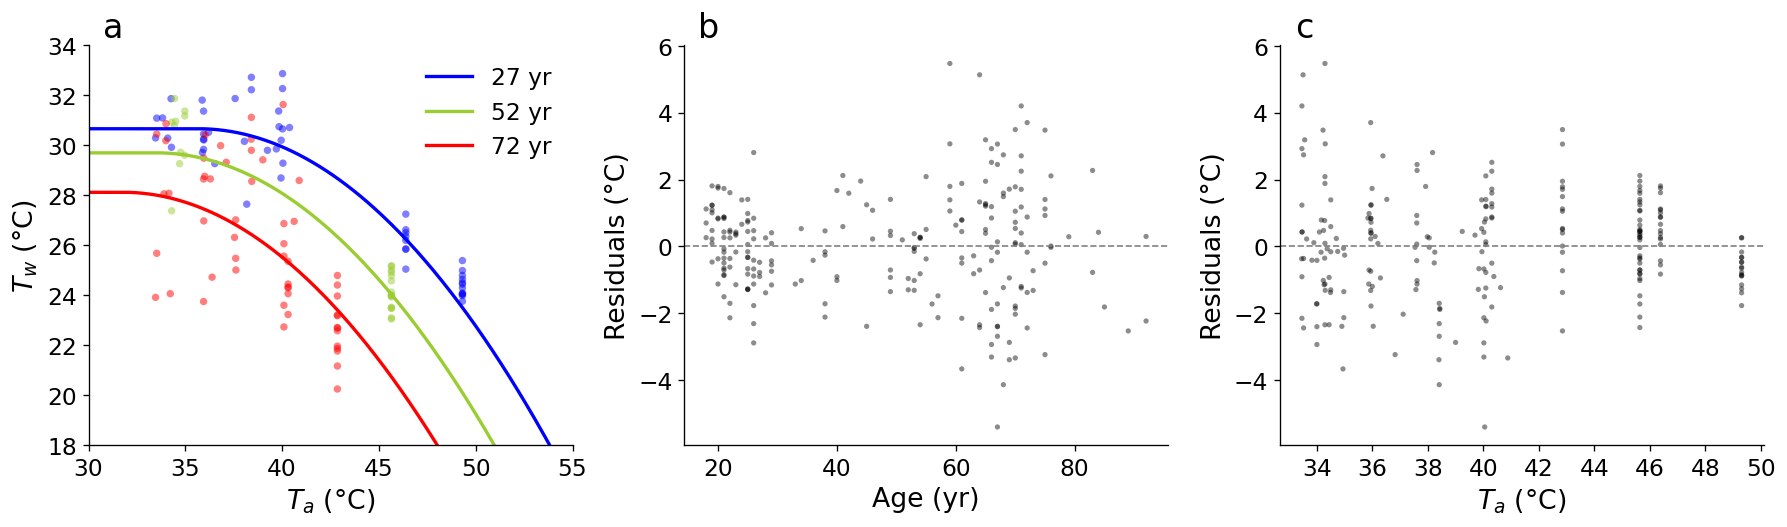

In [30]:
plot_model_results(
    result     = result,
    age=age, tdb=tdb, tw=tw,
    predict_fn = predict,
)

## Interpretation

**Parameter estimates:**

| Parameter | Estimate | Interpretation |
|-----------|----------|----------------|
| $c_{\text{top}}$ | ~30.74 | Maximum platform Tw for the youngest adults (~31°C) |
| $b$ | ~0.00089 | Rate at which platform declines with age |
| $\text{age}_0$ | ~17.9 | Onset age — but note large SE, poorly identified (see below) |
| $a$ | ~0.038 | Curvature of the Tdb effect — highly significant |
| $x_{00}$ | ~38.0 | Tdb inflection intercept — highly significant |
| $x_{01}$ | ~−0.086 | **Tdb inflection declines ~0.09°C per year of age** — highly significant (p<0.001) |

**Key finding**
- **$x_{01}$ is strongly significant and negative:** This confirms the physiological expectation: the temperature at which $T_w$ begins to decline decreases with age.



- **$b$ is strongly strongly significant and negative:** This confirms the physiological expectation: heat tolerance declines with age.


- **Note on $\text{age}_0$:** The age-of-onset $\text{age}_0$ has a large standard error, suggesting the data cannot precisely pin down when the platform decline begins. This due to limited sample size near the yong-end of the age range.


- **Residuals (panels c and d):** No strong systematic pattern vs Age or Tdb. This indicates our model captures the main structure in the data adequately.

**Fig. S13** Modeling heat compensability thresholds as a continuous function of ambient temperature and age. (a) Fitted threshold curves at ages 27, 52, and 72 years with surrounding dots showing observations for participants within ±5 years of the respective age. (b) Model residuals plotted against participant age. (c) Model residuals plotted against ambient temperature.